In [4]:

!pip install lifelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
import io



In [16]:
data = pd.read_csv("C:/Users/DELL-PC/Desktop/Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1.0,0,0 phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0.0
1,5575-GNVDE,Male,0,0,0,34.0,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0.0
2,3668-QPYBK,Male,0,0,0,2.0,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1.0
3,7795-CFOCW,Male,0,0,0,45.0,0,0 phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0.0
4,9237-HQITU,Female,0,0,0,2.0,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1.0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [8]:
kmf = KaplanMeierFitter() 
# The 1st arg accepts an array or pd.Series of individual survival times
# The 2nd arg accepts an array or pd.Series that indicates if the event 
# interest (or death) occured.
kmf.fit(durations = data.tenure, 
        event_observed = data.Churn)
kmf.event_table


,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,11,0,11,7043,7043
1.0,613,380,233,0,7032
2.0,238,123,115,0,6419
3.0,200,94,106,0,6181
4.0,176,83,93,0,5981
...,...,...,...,...,...
68.0,100,9,91,0,846
69.0,95,8,87,0,746
70.0,119,11,108,0,651


In [18]:
# get the values for time = 0 from the survival table
event_at_0 = kmf.event_table.iloc[0, :]
# now calculate the survival probability for t = 0
surv_for_0 =  (event_at_0.at_risk - event_at_0.observed) / event_at_0.at_risk
surv_for_0
# Calculate the survival probability for t = 1
event_at_1 = kmf.event_table.iloc[1, :]
surv_for_1 =  (event_at_1.at_risk - event_at_1.observed) / event_at_1.at_risk
surv_for_1
# Calculate the survival probability for t = 2
event_at_2 = kmf.event_table.iloc[2, :]
surv_for_2 =  (event_at_2.at_risk - event_at_2.observed) / event_at_2.at_risk
surv_for_2


0.9808381367814302

In [11]:
# The probability that an NFL player has a career longer than 2 years
surv_after_2 = surv_for_0 * surv_for_1 * surv_for_2
surv_after_2



0.9278349382636624

In [12]:
kmf.predict(2)

kmf.predict([1,3,5,10])

kmf.survival_function_

kmf.median_survival_time_

inf

Plotting the Kaplan-Meier Estimate

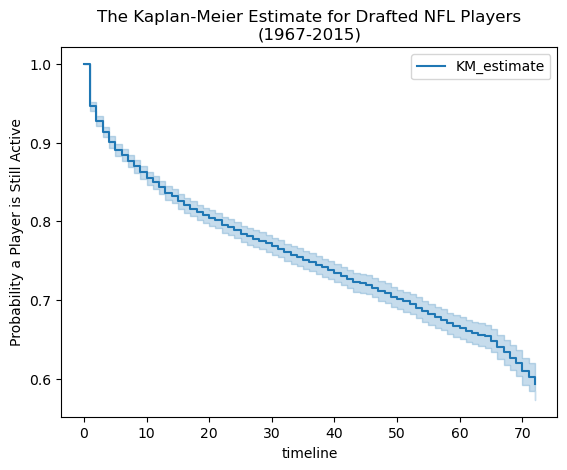

In [13]:
# plot the KM estimate
kmf.plot()
# Add title and y-axis label
plt.title("The Kaplan-Meier Estimate for Drafted NFL Players\n(1967-2015)")
plt.ylabel("Probability a Player is Still Active")

plt.show()